**INSTALL FAKER**

In [1]:
pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 25.1 MB/s eta 0:00:00


In [2]:
from faker import Faker

In [3]:
fake = Faker()

**DATA SET**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [6]:
data = []

for i in range(10000):
    data.append({
        "Patient_ID": i+1,
        "Age": np.random.randint(20, 81),
        "Gender": np.random.choice(["Male", "Female"]),
        "Blood_Pressure": np.random.randint(80, 181),
        "Sugar_Level": np.random.randint(70, 201),
        "Cholesterol": np.random.randint(150, 301),
        "Heart_Rate": np.random.randint(60, 121)
    })

df = pd.DataFrame(data)
df.head()

,Patient_ID,Age,Gender,Blood_Pressure,Sugar_Level,Cholesterol,Heart_Rate
0,1,64,Female,148,150,176,99
1,2,44,Male,141,199,215,114
2,3,49,Male,82,129,212,94
3,4,39,Male,167,78,188,94
4,5,74,Female,166,192,261,93


In [7]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Patient_ID      10000 non-null  int64 
 1   Age             10000 non-null  int64 
 2   Gender          10000 non-null  object
 3   Blood_Pressure  10000 non-null  int64 
 4   Sugar_Level     10000 non-null  int64 
 5   Cholesterol     10000 non-null  int64 
 6   Heart_Rate      10000 non-null  int64 
dtypes: int64(6), object(1)
memory usage: 547.0+ KB


,Patient_ID,Age,Blood_Pressure,Sugar_Level,Cholesterol,Heart_Rate
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,49.854600,129.896300,134.477000,225.499900,89.977700
std,2886.89568,17.615439,29.053959,37.824407,43.531597,17.465031
min,1.00000,20.000000,80.000000,70.000000,150.000000,60.000000
25%,2500.75000,35.000000,105.000000,101.000000,188.000000,75.000000
50%,5000.50000,50.000000,130.000000,134.500000,226.000000,90.000000
75%,7500.25000,65.000000,155.000000,167.000000,263.000000,105.000000
max,10000.00000,80.000000,180.000000,200.000000,300.000000,120.000000


In [9]:
def risk(row):
    if row["Blood_Pressure"] > 140 or row["Sugar_Level"] > 180 or row["Cholesterol"] > 240:
        return "High"
    elif row["Blood_Pressure"] > 120 or row["Sugar_Level"] > 140:
        return "Medium"
    else:
        return "Low"

df["Risk"] = df.apply(risk, axis=1)

In [20]:
high_risk = df[df["Risk"] == "High"]
high_risk.head()

,Patient_ID,Age,Gender,Blood_Pressure,Sugar_Level,Cholesterol,Heart_Rate,Risk
0,1,64,Female,148,150,176,99,High
1,2,44,Male,141,199,215,114,High
3,4,39,Male,167,78,188,94,High
4,5,74,Female,166,192,261,93,High
5,6,73,Female,153,87,229,80,High


In [21]:
df["Age_Group"] = pd.cut(df["Age"],
                        bins=[20,30,40,50,60,70,80],
                        labels=["20-30","30-40","40-50","50-60","60-70","70-80"])

df.groupby("Age_Group")["Blood_Pressure"].mean()

/tmp/ipykernel_13975/2792896681.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Age_Group")["Blood_Pressure"].mean()


,Blood_Pressure
Age_Group,
20-30,131.618613
30-40,129.152432
40-50,128.543915
50-60,129.871718
60-70,129.459476
70-80,130.606396


In [22]:
df.groupby("Gender").mean(numeric_only=True)

,Patient_ID,Age,Blood_Pressure,Sugar_Level,Cholesterol,Heart_Rate
Gender,,,,,,
Female,5021.104343,49.973276,129.769896,134.476321,225.425231,89.502063
Male,4979.148850,49.731623,130.027286,134.477703,225.577276,90.470576


In [23]:
df["Risk"].value_counts()

,count
Risk,
High,6921
Medium,1701
Low,1378


**BAR CHART**

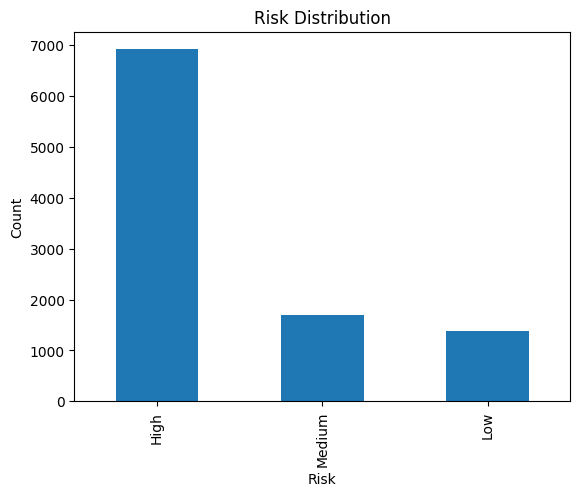

In [10]:
df["Risk"].value_counts().plot(kind="bar")
plt.title("Risk Distribution")
plt.xlabel("Risk")
plt.ylabel("Count")
plt.show()

**PIE CHART**

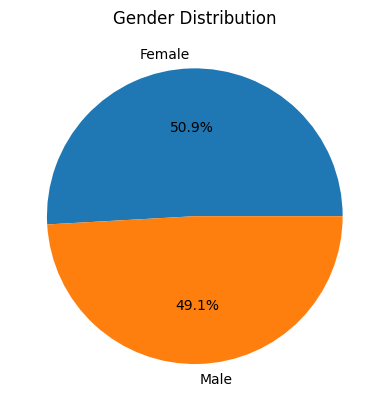

In [11]:
df["Gender"].value_counts().plot(kind="pie", autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

**HISTOGRAM**

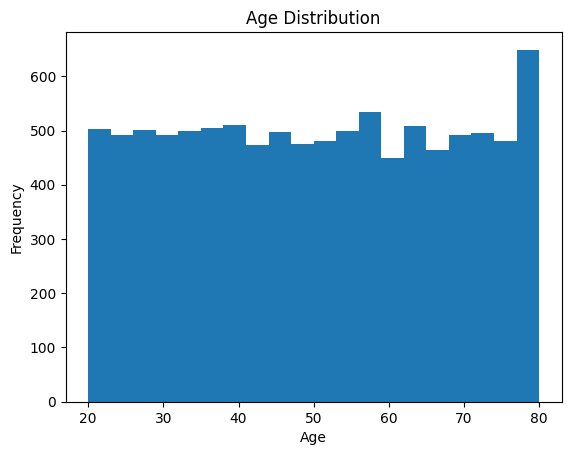

In [14]:
plt.hist(df["Age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

**SCATTER PLOT**

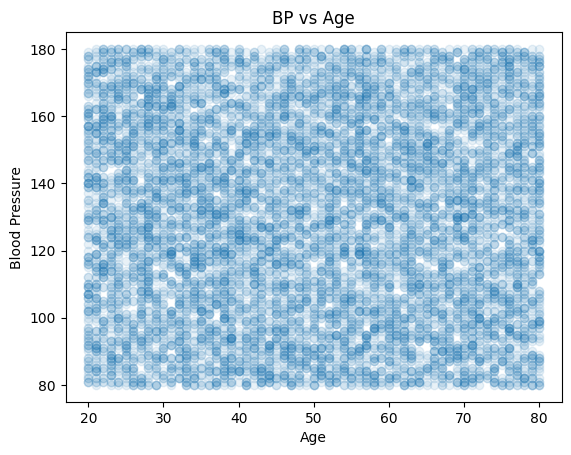

In [26]:
plt.scatter(df["Age"], df["Blood_Pressure"], alpha=0.1)
plt.title("BP vs Age")
plt.xlabel("Age")
plt.ylabel("Blood Pressure")
plt.show()

**BOX PLOT**

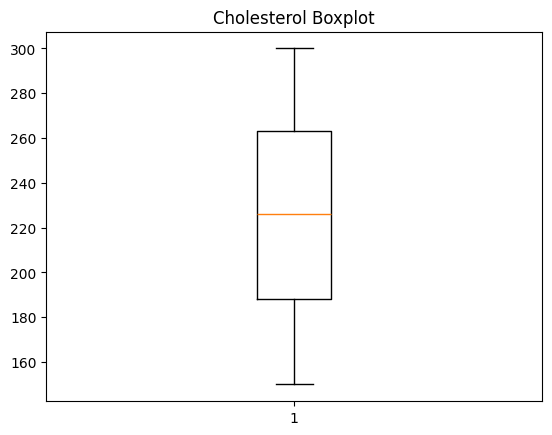

In [27]:
plt.boxplot(df["Cholesterol"])
plt.title("Cholesterol Boxplot")
plt.show()

**HEATMAP**

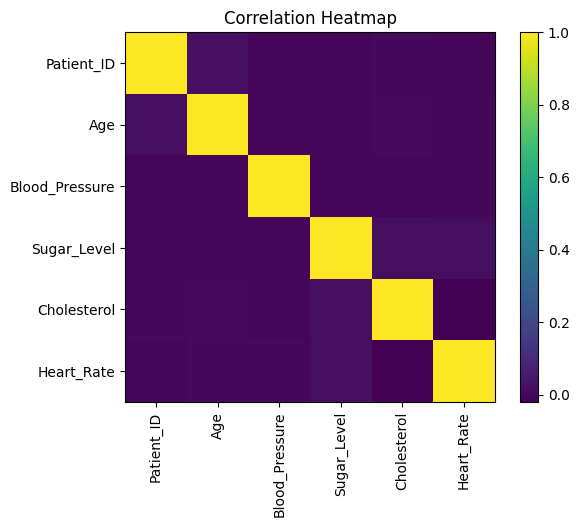

In [28]:
corr = df.corr(numeric_only=True)

plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")
plt.show()